In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")

In [3]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count
print(scale_pos_weight)

577.2868020304569


In [6]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [8]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.87      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962

[[56832    32]
 [   13    85]]
ROC-AUC: 0.9816106169535906
PR-AUC: 0.8667665288954811


Logistic Regression PR-AUC=0.7189705771419241,
XGBoost PR-AUC=0.8667665288954811,
Logistic Regression Recall=0.92
XGBoost Recall=0.87

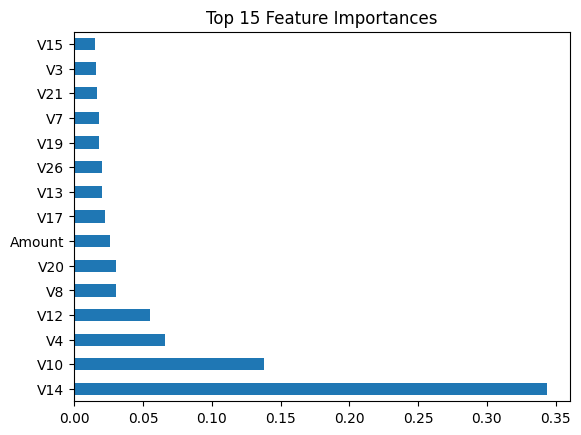

In [9]:
import matplotlib.pyplot as plt

importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(15).plot(kind="barh")
plt.title("Top 15 Feature Importances")
plt.show()

In [10]:
import joblib

joblib.dump(model, "../models/xgboost_model.pkl")

['../models/xgboost_model.pkl']

In [11]:
#Threshold Tuning

In [12]:
from sklearn.metrics import precision_recall_curve

In [13]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_proba
)

In [14]:
threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

threshold_df.head()

,threshold,precision,recall
0,0.000029,0.001720,1.0
1,0.000030,0.001720,1.0
2,0.000030,0.001721,1.0
3,0.000032,0.001721,1.0
4,0.000032,0.001721,1.0


In [15]:
threshold_df["f1_score"] = (
    2
    * threshold_df["precision"]
    * threshold_df["recall"]
    / (
        threshold_df["precision"]
        + threshold_df["recall"]
        + 1e-10
    )
)

In [16]:
best_row = threshold_df.loc[
    threshold_df["f1_score"].idxmax()
]

best_row

threshold    0.911645
precision    0.908046
recall       0.806122
f1_score     0.854054
Name: 55669, dtype: float64

In [17]:
best_threshold = best_row["threshold"]
print("Best Threshold:", best_threshold)

Best Threshold: 0.9116453528404236


In [18]:
y_pred_custom = (y_proba >= best_threshold).astype(int)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.81      0.85        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

[[56856     8]
 [   19    79]]


In [20]:
threshold_df.sort_values(
    "f1_score",
    ascending=False
).head(10)

,threshold,precision,recall,f1_score
55669,0.911645,0.908046,0.806122,0.854054
55664,0.862331,0.880435,0.826531,0.852632
55671,0.969883,0.917647,0.795918,0.852459
55666,0.870307,0.888889,0.816327,0.851064
55668,0.898804,0.897727,0.806122,0.849462
55663,0.812311,0.870968,0.826531,0.848168
55670,0.933043,0.906977,0.795918,0.847826
55665,0.869790,0.879121,0.816327,0.846561
55672,0.977641,0.916667,0.785714,0.846154
55667,0.879160,0.887640,0.806122,0.844920


In [21]:
joblib.dump(best_threshold, "../models/best_threshold.pkl")

['../models/best_threshold.pkl']

In [22]:
import shap

In [23]:
explainer = shap.TreeExplainer(model)

In [24]:
X_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_sample)

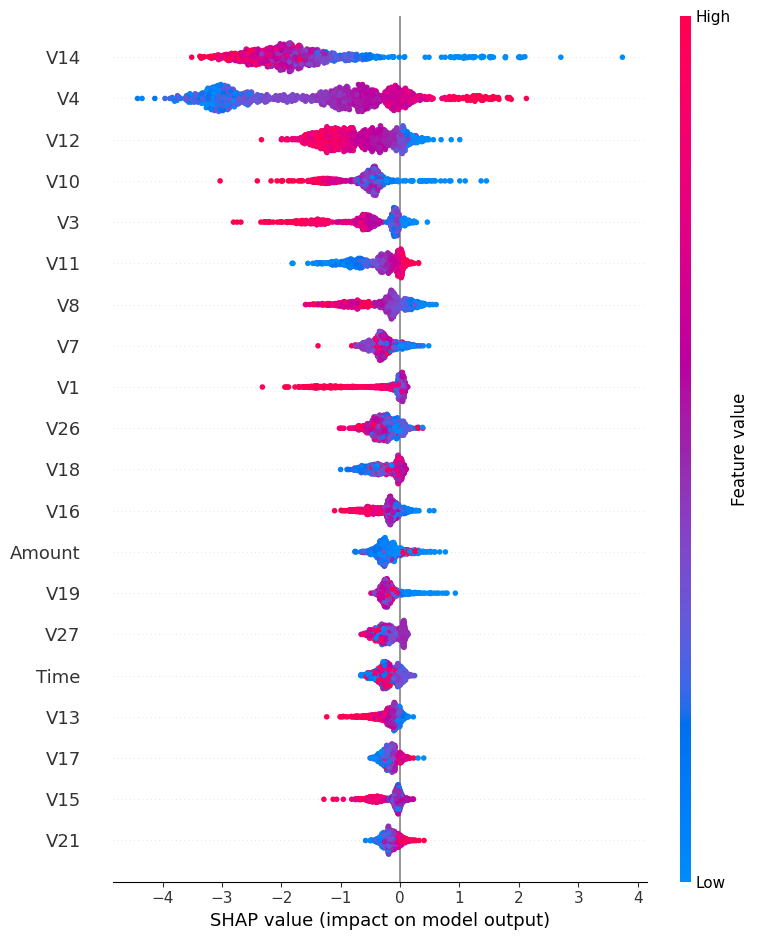

In [25]:
shap.summary_plot(shap_values, X_sample)

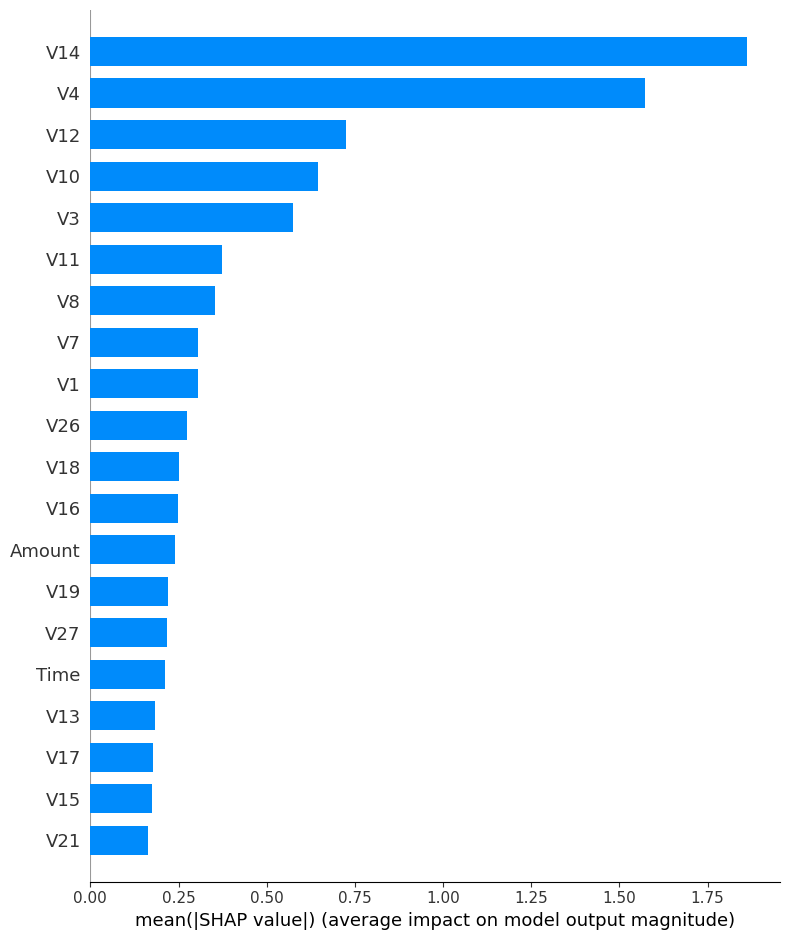

In [26]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

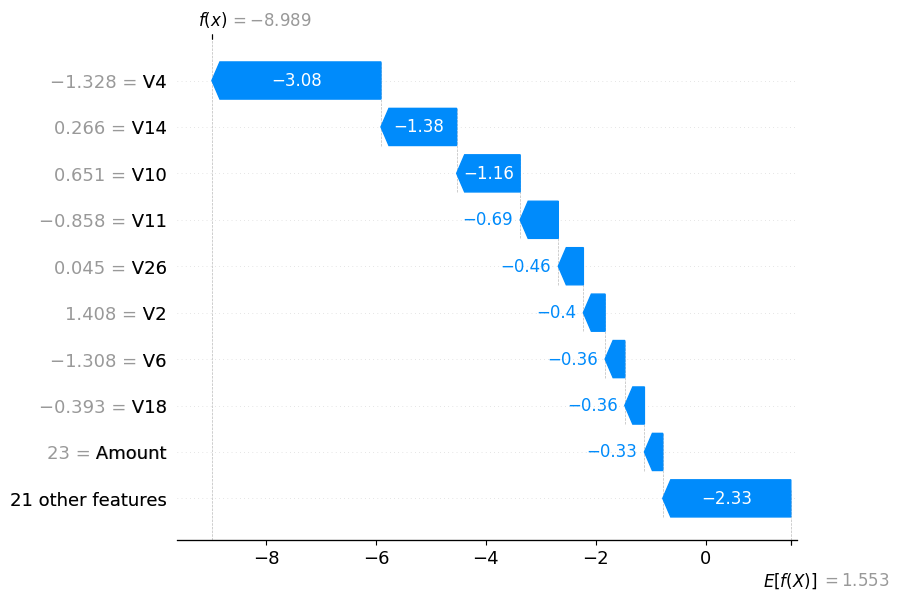

In [27]:
transaction_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[transaction_index],
        base_values=explainer.expected_value,
        data=X_sample.iloc[transaction_index],
        feature_names=X_sample.columns
    )
)

In [28]:
print("Predicted probability:", y_proba[0])
print("Actual class:", y_test.iloc[0])

Predicted probability: 0.00012475635
Actual class: 0


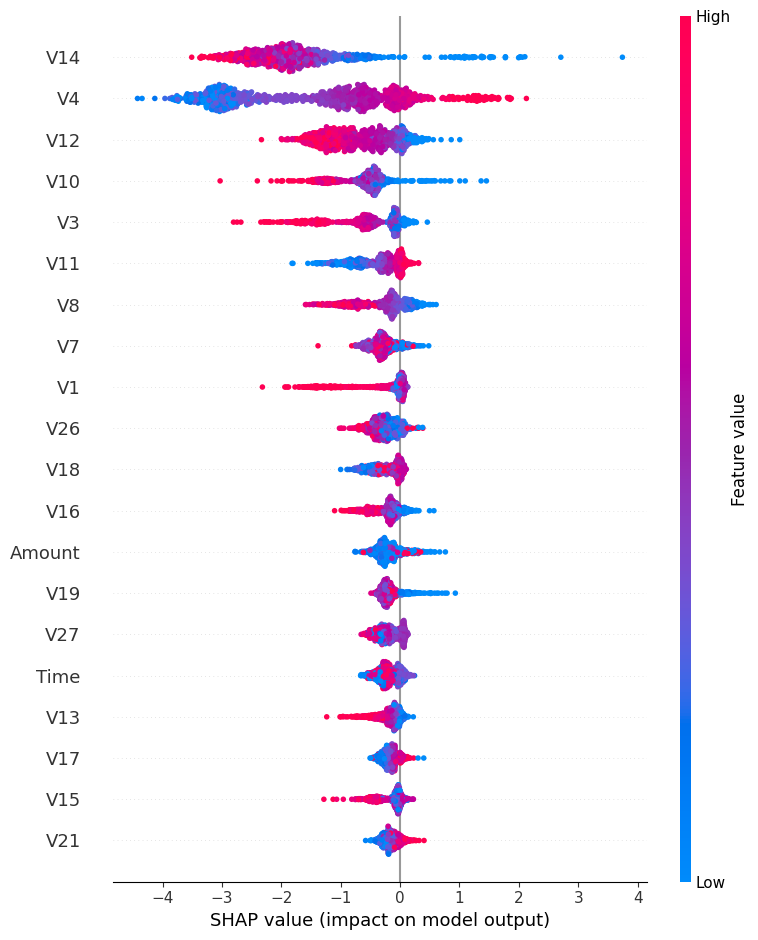

In [29]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig("../reports/shap_summary.png", bbox_inches="tight")

In [30]:
feature_names = X.columns.tolist()
joblib.dump(feature_names, "../models/feature_names.pkl")

['../models/feature_names.pkl']

In [31]:
metadata = {
    "model_name": "XGBoost Fraud Detector",
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
    "threshold": float(best_threshold),
    "n_features": len(feature_names)
}

joblib.dump(metadata, "../models/metadata.pkl")

['../models/metadata.pkl']

In [32]:
import os

os.listdir("../models")

['best_threshold.pkl',
 'feature_names.pkl',
 'metadata.pkl',
 'xgboost_model.pkl']

In [33]:
loaded_model = joblib.load("../models/xgboost_model.pkl")
loaded_threshold = joblib.load("../models/best_threshold.pkl")
loaded_features = joblib.load("../models/feature_names.pkl")
loaded_metadata = joblib.load("../models/metadata.pkl")

In [34]:
sample = X_test.iloc[:1]
sample_proba = loaded_model.predict_proba(sample)[:, 1][0]

print("Fraud probability:", sample_proba)
print("Threshold:", loaded_threshold)
print("Predicted class:", int(sample_proba >= loaded_threshold))

Fraud probability: 0.00012475635
Threshold: 0.9116453528404236
Predicted class: 0
